## EDA Model - E-Commerce Reviews


#### Dataset: 
Olist, and André Sionek. (2018). Brazilian E-Commerce Public Dataset by Olist [Dataset]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/195341

In [160]:
# Import the main analysis libraries used throughout the EDA notebook.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import copy

In [161]:
# Resolve project paths and load the denormalized dataset from the helper module.
from pathlib import Path
import sys

project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
src_path = project_root / 'src'

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from data_cleaning_tools import denormalize_olist_datasets

datasets_path = project_root / 'datasets'
df_raw_data = denormalize_olist_datasets(datasets_dir=datasets_path, drop_nulls=True)


In [162]:
# Inspect the raw denormalized dataframe structure before feature engineering.
df_raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11112 entries, 0 to 11111
Data columns (total 49 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       11112 non-null  str           
 1   order_item_id                  11112 non-null  int64         
 2   product_id                     11112 non-null  str           
 3   seller_id                      11112 non-null  str           
 4   shipping_limit_date            11112 non-null  datetime64[us]
 5   price                          11112 non-null  float64       
 6   freight_value                  11112 non-null  float64       
 7   product_category_name          11112 non-null  str           
 8   product_name_lenght            11112 non-null  float64       
 9   product_description_lenght     11112 non-null  float64       
 10  product_photos_qty             11112 non-null  float64       
 11  product_weight_g          

In [163]:
# Create logistics and size-related features from the original denormalized dataframe.
df_raw_featured = df_raw_data.copy()

df_raw_featured['delivery_delay'] = (
    df_raw_featured['order_delivered_customer_date'] - df_raw_featured['order_estimated_delivery_date']
).dt.total_seconds().div(86400).astype(float)

df_raw_featured['shipping_time'] = (
    df_raw_featured['order_delivered_customer_date'] - df_raw_featured['order_purchase_timestamp']
).dt.total_seconds().div(86400).astype(float)

df_raw_featured['approval_delay'] = (
    df_raw_featured['order_approved_at'] - df_raw_featured['order_purchase_timestamp']
).dt.total_seconds().div(86400).astype(float)

df_raw_featured['freight_ratio'] = np.where(
    df_raw_featured['price'] > 0,
    df_raw_featured['freight_value'] / df_raw_featured['price'],
    np.nan
)

df_raw_featured['product_volume_cm3'] = (
    df_raw_featured['product_length_cm']
    * df_raw_featured['product_height_cm']
    * df_raw_featured['product_width_cm']
)

df_raw_featured['is_late_delivery'] = (df_raw_featured['delivery_delay'] > 0).astype(int)

time_feature_columns = ['delivery_delay', 'shipping_time', 'approval_delay']
df_raw_featured[time_feature_columns].dtypes

delivery_delay    float64
shipping_time     float64
approval_delay    float64
dtype: object

In [164]:
# Keep the columns needed for the enriched EDA dataframe and remove invalid numeric values.
analysis_columns = [
    'order_id',
    'product_category_name',
    'product_category_name_english',
    'payment_type',
    'customer_geo_state',
    'price',
    'freight_value',
    'payment_value_total',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_volume_cm3',
    'freight_ratio',
    'shipping_time',
    'approval_delay',
    'delivery_delay',
    'is_late_delivery',
    'review_score'
]

df_rn_features = df_raw_featured[analysis_columns].replace([np.inf, -np.inf], np.nan).dropna().copy()
df_rn_features.head()

,order_id,product_category_name,product_category_name_english,payment_type,customer_geo_state,price,freight_value,payment_value_total,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,freight_ratio,shipping_time,approval_delay,delivery_delay,is_late_delivery,review_score
0,0006ec9db01a64e59a68b2c340bf65a7,cama_mesa_banho,bed_bath_table,credit_card,RJ,74.0,23.32,97.32,1383.0,50.0,10.0,40.0,20000.0,0.315135,6.333310,0.013924,-21.955382,0,5.0
1,000aed2e25dbad2f9ddb70584c5a2ded,perfumaria,perfumery,credit_card,SP,144.0,8.77,152.77,468.0,23.0,18.0,19.0,7866.0,0.060903,6.842280,0.016262,-3.301030,0,1.0
2,00130c0eee84a3d909e75bc08c5c3ca1,alimentos,food,boleto,SP,27.9,7.94,35.84,150.0,17.0,13.0,13.0,2873.0,0.284588,1.757928,0.332917,-6.355266,0,5.0
3,001e7cf2ad6bef3ade12ebc56ceaf0f3,beleza_saude,health_beauty,credit_card,MG,35.9,15.20,51.10,1614.0,31.0,16.0,28.0,13888.0,0.423398,16.318750,0.021146,-0.244178,0,1.0
4,002175704e8b209f61b9ad5cfd92b60e,audio,audio,credit_card,SP,109.9,13.21,123.11,588.0,19.0,14.0,17.0,4522.0,0.120200,10.350914,2.216238,-11.139769,0,4.0


In [165]:
# Build a simpler raw subset to inspect the original review score relationships.
df_rn = df_raw_data[['order_id', 'product_category_name', 'price', 'payment_type', 'payment_value_total', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_geo_state', 'review_score']].copy()

In [166]:
# Preview the simplified dataframe.
df_rn.head(10)

,order_id,product_category_name,price,payment_type,payment_value_total,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_geo_state,review_score
0,0006ec9db01a64e59a68b2c340bf65a7,cama_mesa_banho,74.00,credit_card,97.32,1383.0,50.0,10.0,40.0,RJ,5.0
1,000aed2e25dbad2f9ddb70584c5a2ded,perfumaria,144.00,credit_card,152.77,468.0,23.0,18.0,19.0,SP,1.0
2,00130c0eee84a3d909e75bc08c5c3ca1,alimentos,27.90,boleto,35.84,150.0,17.0,13.0,13.0,SP,5.0
3,001e7cf2ad6bef3ade12ebc56ceaf0f3,beleza_saude,35.90,credit_card,51.10,1614.0,31.0,16.0,28.0,MG,1.0
4,002175704e8b209f61b9ad5cfd92b60e,audio,109.90,credit_card,123.11,588.0,19.0,14.0,17.0,SP,4.0
5,0025c5d1a8ca53a240ec2634bb4492ea,esporte_lazer,390.00,credit_card,419.39,2100.0,36.0,9.0,14.0,CE,5.0
6,0036757472ece3dde52fd4bfd929c90e,moveis_escritorio,136.99,debit_card,203.03,15475.0,81.0,7.0,83.0,SP,2.0
7,0039500db36d50d7d0bfaf23723550f3,esporte_lazer,169.90,credit_card,203.23,1092.0,30.0,26.0,22.0,AL,5.0
8,003cc6161d7a2593f2525cce0c330d32,utilidades_domesticas,85.00,credit_card,97.90,1800.0,30.0,30.0,30.0,SP,5.0
9,003edccf16bc5ec447f592913b3df2b4,telefonia,14.00,credit_card,64.85,217.0,18.0,4.0,13.0,MA,5.0


In [167]:
# Convert review_score into a binary variable for quick exploratory comparisons.
from data_cleaning_tools import numeric_column_to_binary

df = numeric_column_to_binary(df_rn, 'review_score', 3)

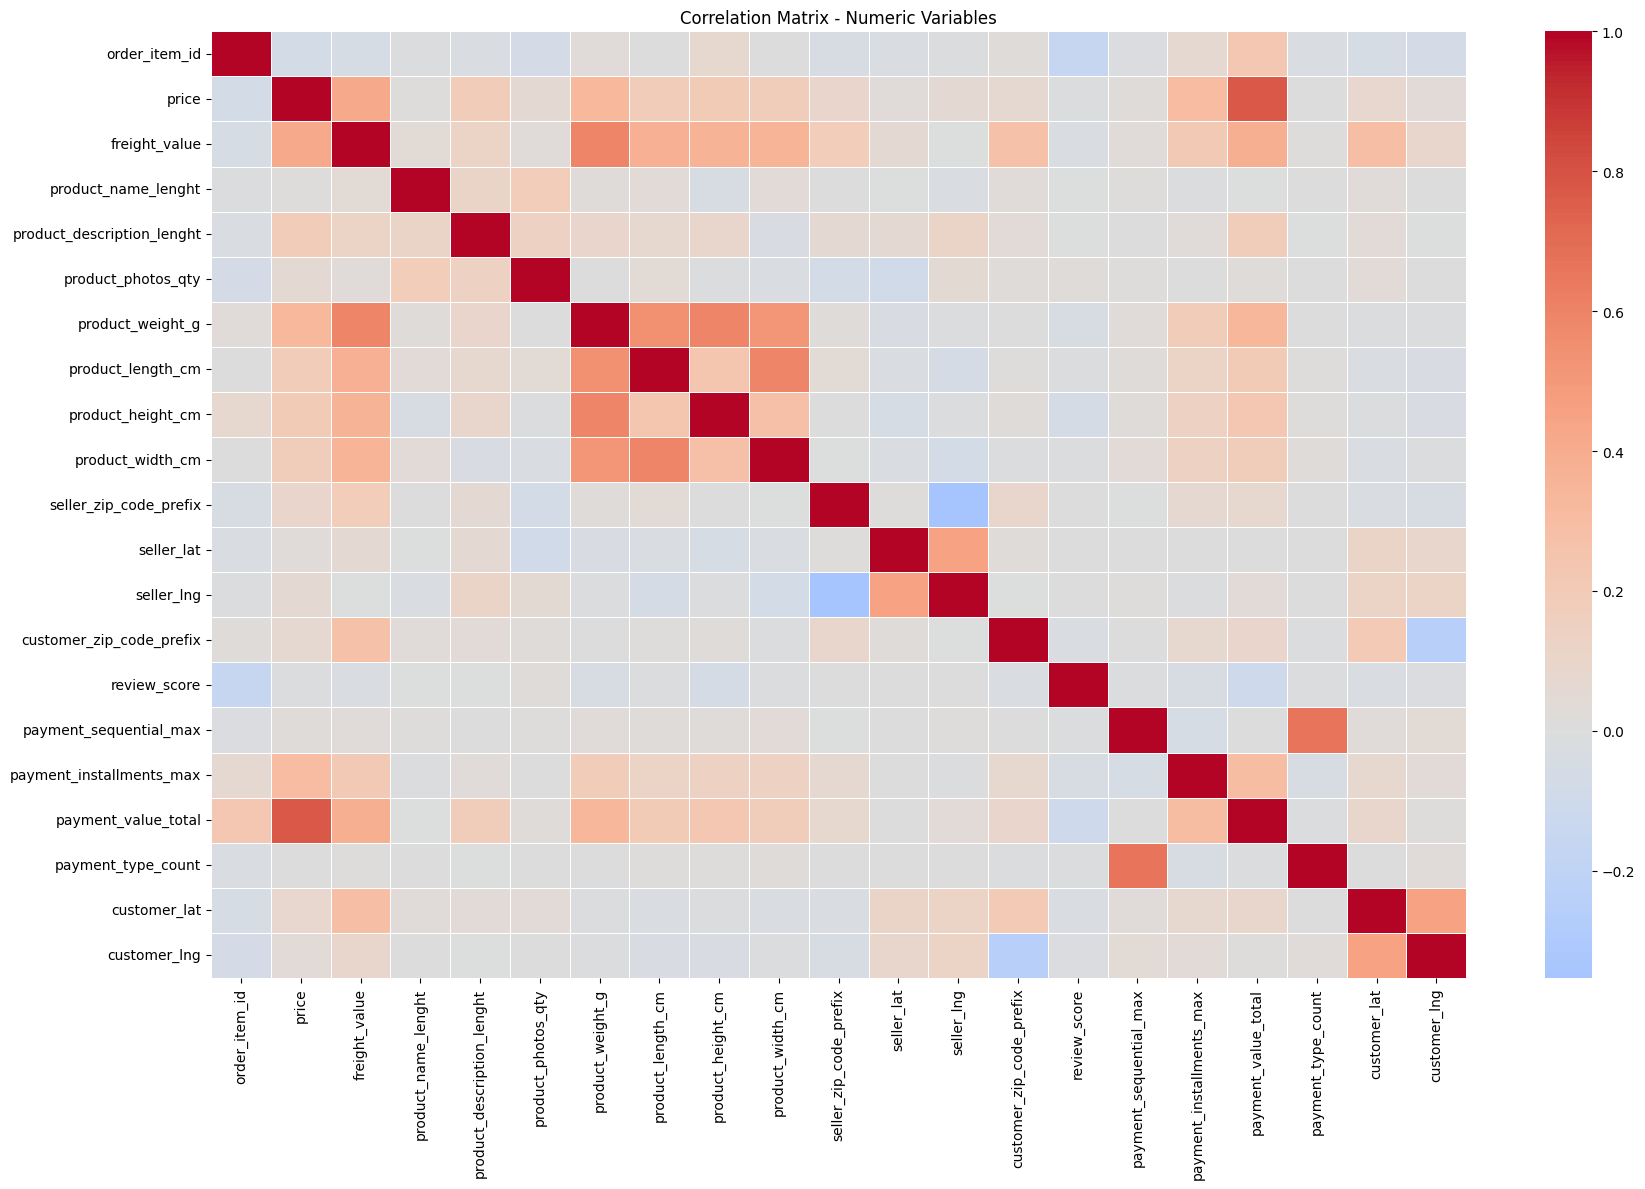

In [168]:
# Plot the correlation heatmap for all numeric variables in the raw denormalized dataset.
import seaborn as sns

numeric_df = df_raw_data.select_dtypes(include=[np.number]).copy()
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(18, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.7)
plt.title('Correlation Matrix - Numeric Variables')
plt.tight_layout()
plt.show()


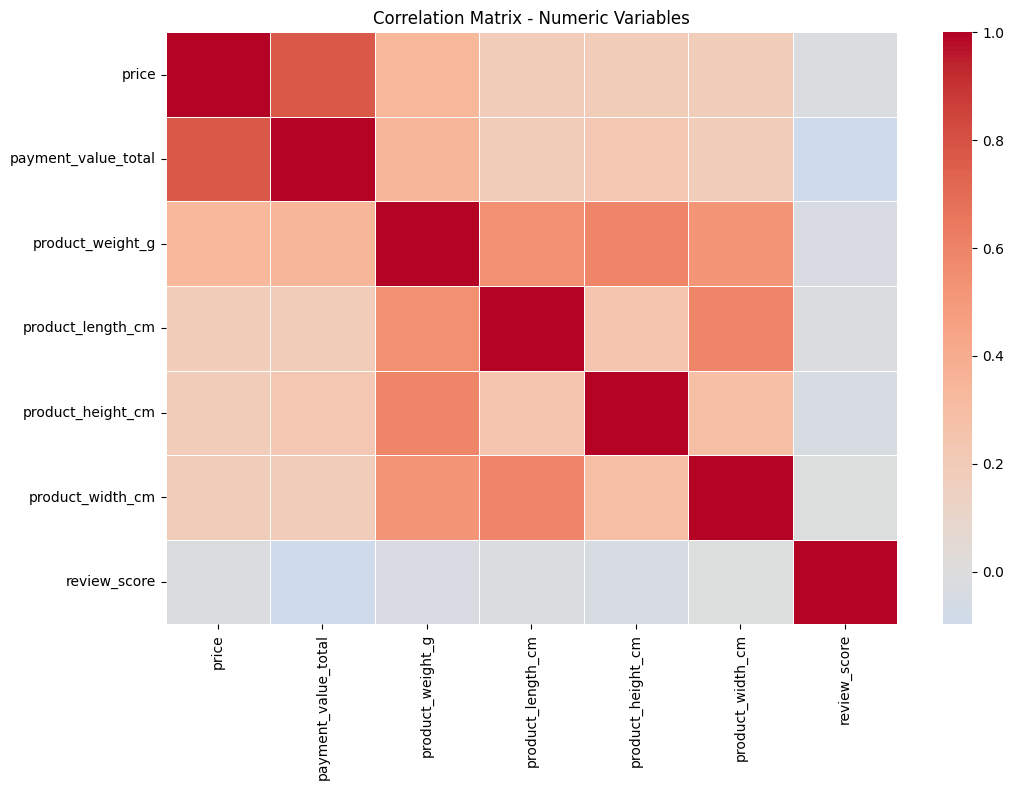

In [169]:
#Plot a compact correlation heatmap for the binary review-score sample dataframe.
numeric_df = df.select_dtypes(include=[np.number]).copy()
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title('Correlation Matrix - Numeric Variables')
plt.tight_layout()
plt.show()

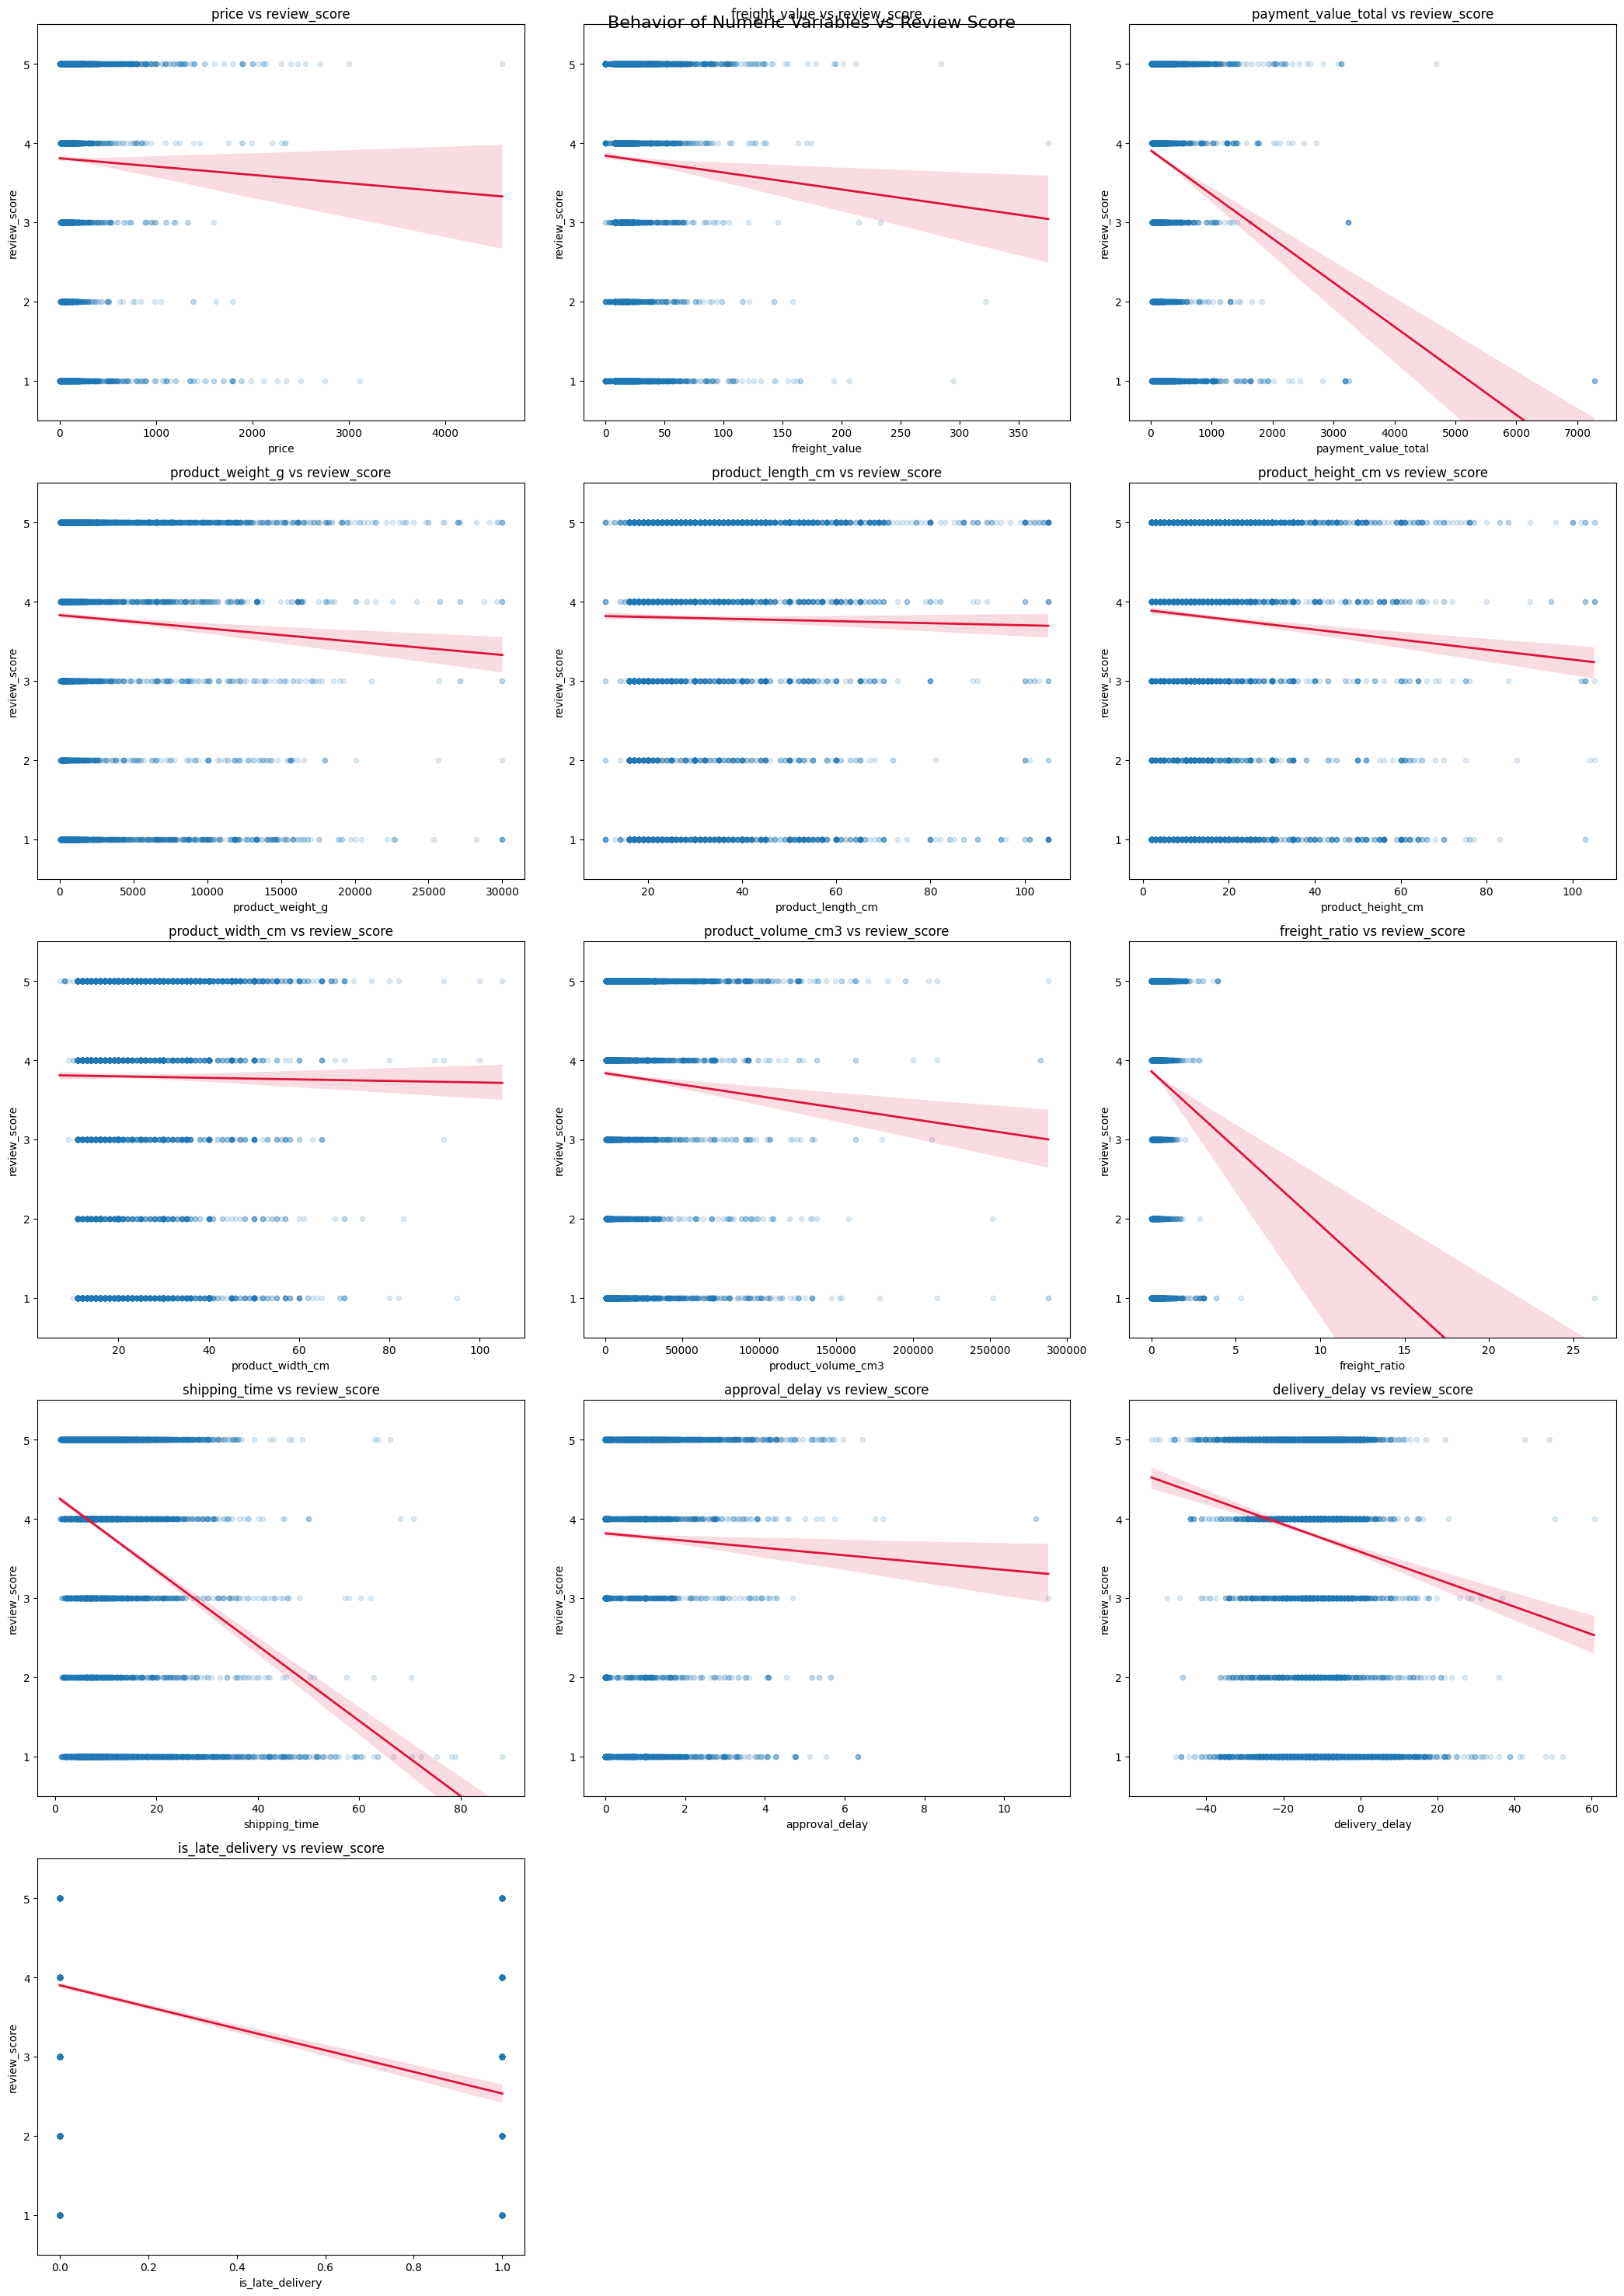

review_score           1.000000
product_width_cm      -0.006762
product_length_cm     -0.012689
price                 -0.013916
approval_delay        -0.025265
freight_value         -0.025439
product_weight_g      -0.040012
product_volume_cm3    -0.041440
freight_ratio         -0.052265
product_height_cm     -0.053079
payment_value_total   -0.110059
delivery_delay        -0.111660
is_late_delivery      -0.233786
shipping_time         -0.246650
Name: review_score, dtype: float64

In [170]:
# Compare numeric variables against review_score using regression plots.
import seaborn as sns

numeric_columns = [
    'price',
    'freight_value',
    'payment_value_total',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_volume_cm3',
    'freight_ratio',
    'shipping_time',
    'approval_delay',
    'delivery_delay',
    'is_late_delivery'
]

plot_df = df_rn_features[numeric_columns + ['review_score']].dropna().copy()

n_cols = 3
n_rows = int(np.ceil(len(numeric_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(21, 6 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.regplot(
        data=plot_df,
        x=column,
        y='review_score',
        scatter_kws={'alpha': 0.15, 's': 20},
        line_kws={'color': 'crimson', 'linewidth': 2},
        ax=ax
    )
    ax.set_title(f'{column} vs review_score')
    ax.set_xlabel(column)
    ax.set_ylabel('review_score')
    ax.set_ylim(0.5, 5.5)

for ax in axes[len(numeric_columns):]:
    ax.axis('off')

plt.suptitle('Behavior of Numeric Variables vs Review Score', fontsize=16)
plt.tight_layout()
plt.show()

review_correlations = plot_df.corr(numeric_only=True)['review_score'].sort_values(ascending=False)
review_correlations

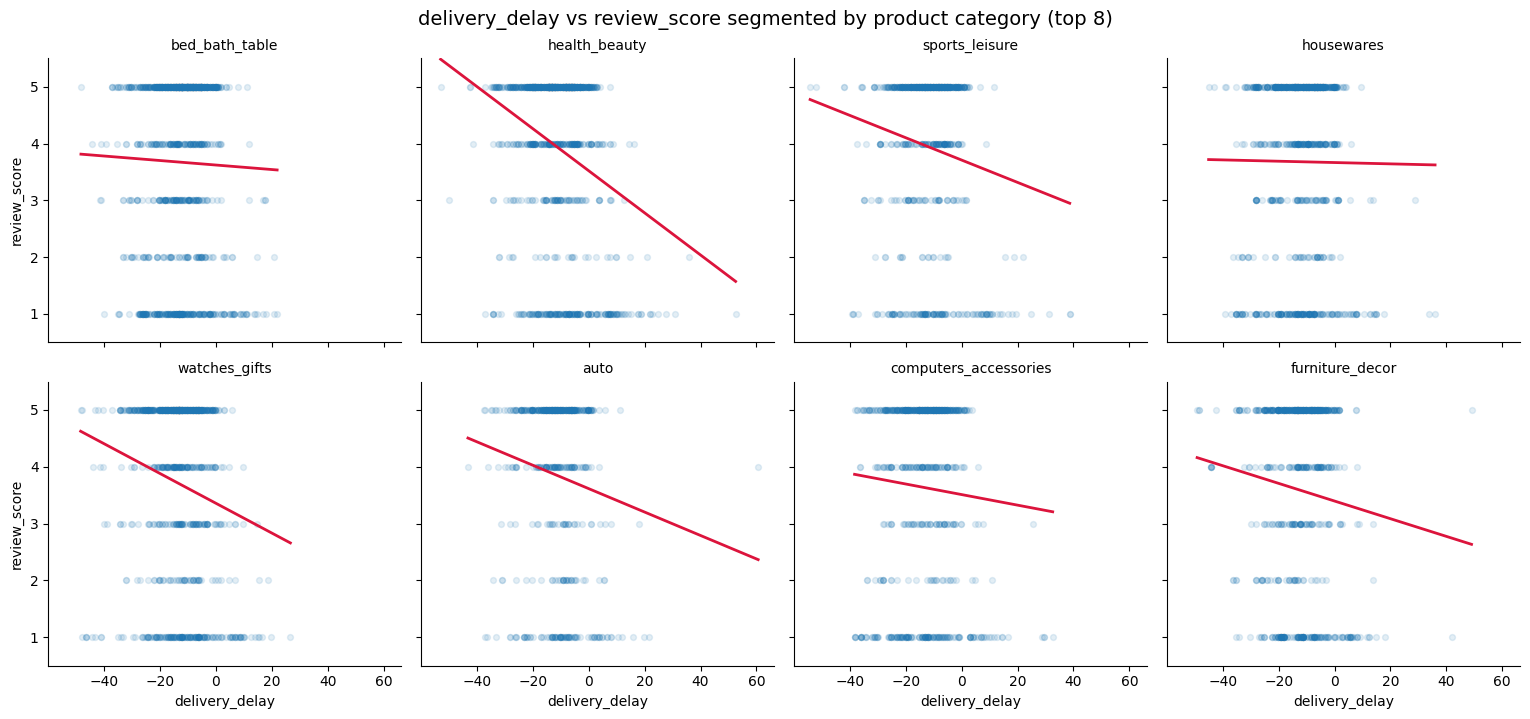

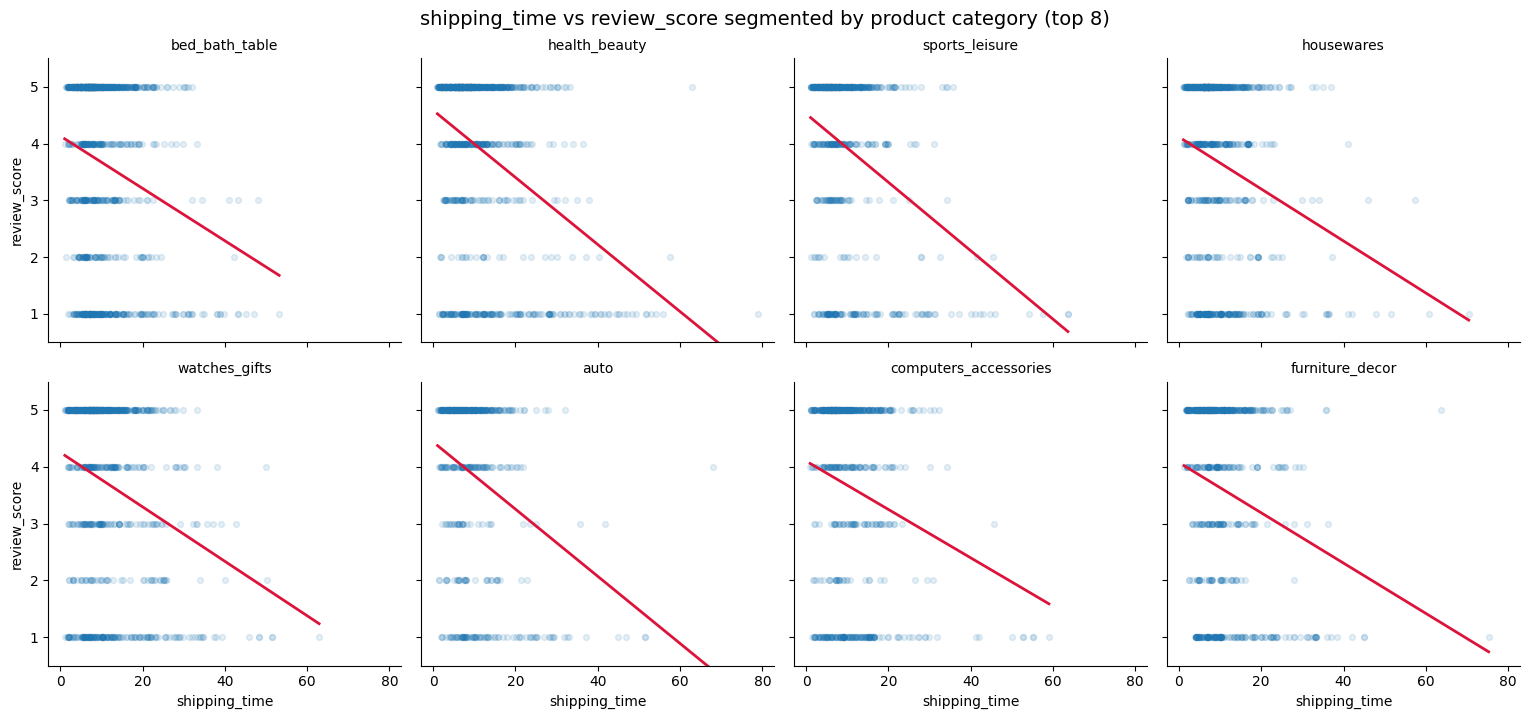

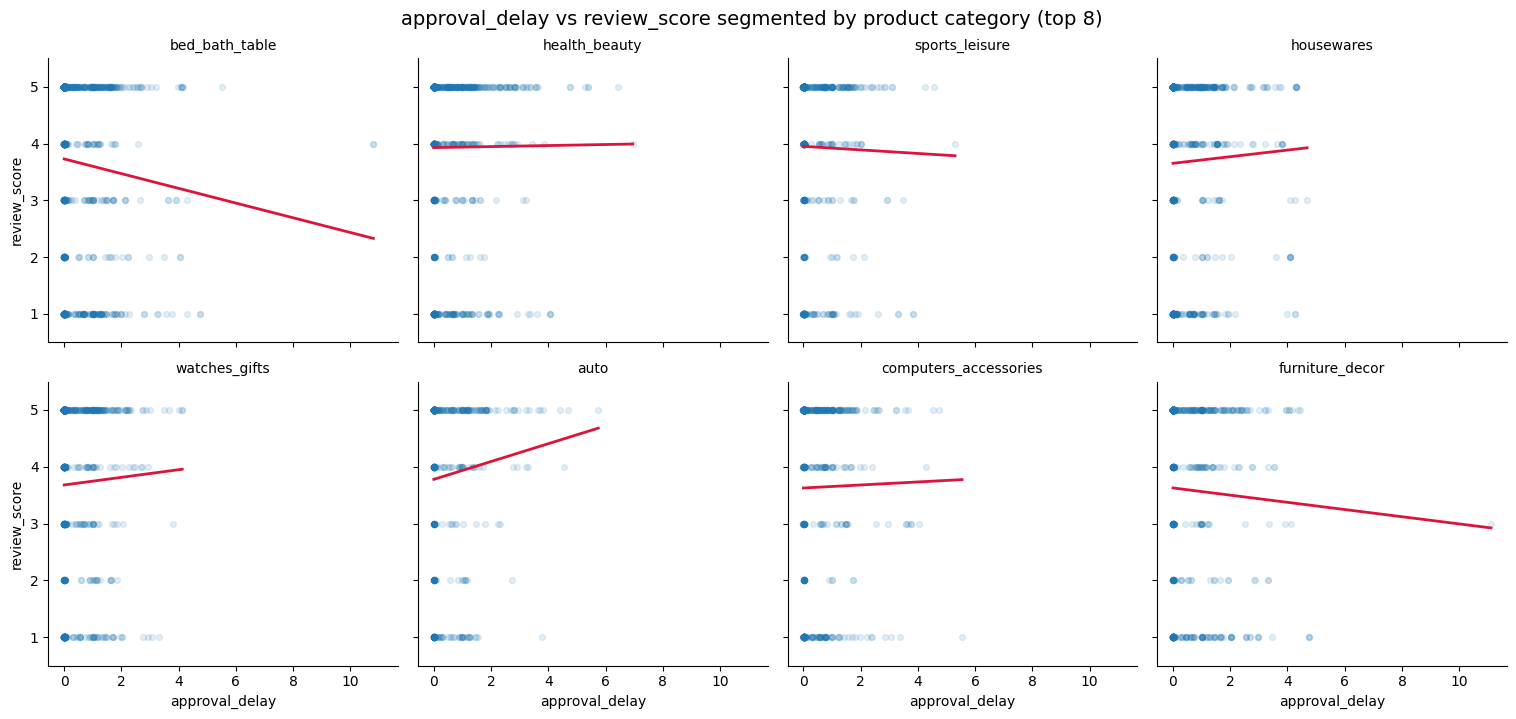

In [171]:
# Visualize time-based variables against review_score for the most frequent product categories.
time_variables = ['delivery_delay', 'shipping_time', 'approval_delay']
top_n_categories = 8
category_column = 'product_category_name_english'

top_categories = (
    df_rn_features[category_column]
    .value_counts()
    .head(top_n_categories)
    .index
)

time_plot_df = df_rn_features[
    df_rn_features[category_column].isin(top_categories)
].copy()

for time_var in time_variables:
    g = sns.lmplot(
        data=time_plot_df,
        x=time_var,
        y='review_score',
        col=category_column,
        col_wrap=4,
        height=3.5,
        aspect=1.1,
        scatter_kws={'alpha': 0.12, 's': 18},
        line_kws={'color': 'crimson', 'linewidth': 2},
        ci=None
    )
    g.set_titles('{col_name}')
    g.set_axis_labels(time_var, 'review_score')
    for ax in g.axes.flatten():
        ax.set_ylim(0.5, 5.5)
    g.fig.suptitle(
        f'{time_var} vs review_score segmented by product category (top {top_n_categories})',
        y=1.02,
        fontsize=14
    )
    plt.show()